# Multi-Task Training

Trains both the general classifier and personalized multi-task heads.

> Generated from `Lab2_multi_task_modal.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import ast
import os
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import numpy as np
import tensorflow as tf
import tensorflow.keras
import keras
from tensorflow.keras import layers
from keras.models import Sequential
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import plotly.io as plt_io
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
import itertools
from sklearn.utils import class_weight
from tensorflow.keras.models import Model
import random
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score, roc_curve, auc, classification_report
%matplotlib inline

# Modeling

## Architecture

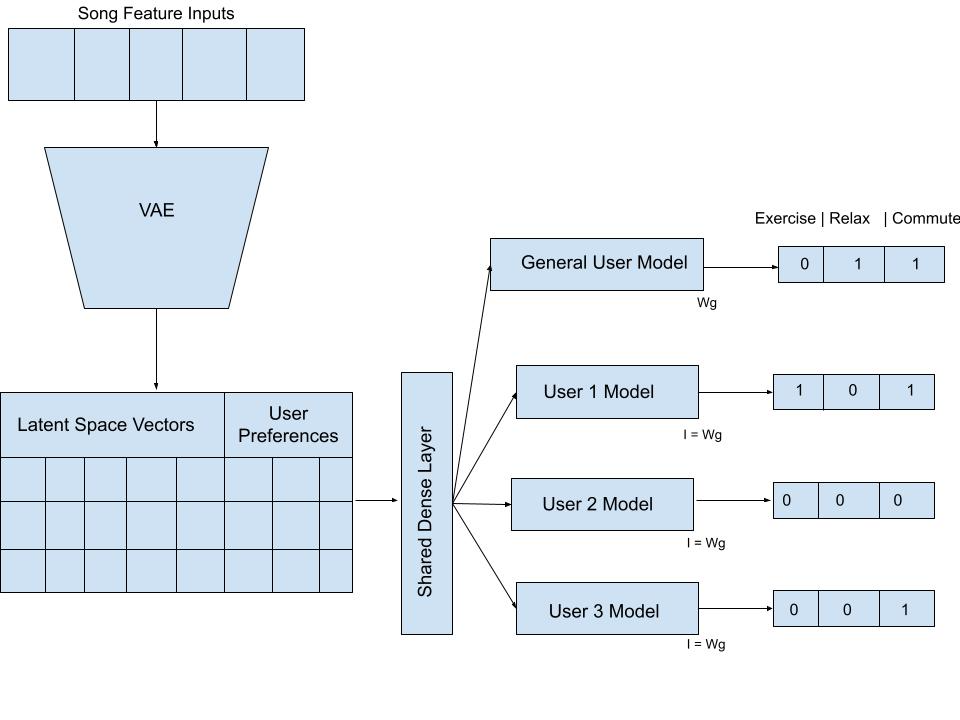

## Training a General Model

In [ ]:
#build a sequential model
general_classifier = Sequential()
general_classifier.add(layers.Dense(input_dim=latent_dim, units=12, activation='relu', name='shared_input_layer'))
general_classifier.add(layers.Dense(input_dim=latent_dim, units=9, activation='relu', name='mid_dense_9'))
general_classifier.add(layers.Dense(input_dim=latent_dim, units=7, activation='relu', name='mid_dense_7'))
general_classifier.add(layers.Dense(input_dim=latent_dim, units=3, activation='sigmoid', name='output_layer')) 

In [ ]:
gen_X_train = X_train.drop(columns=['user'])
gen_y_train = y_train.drop(columns=['user'])
gen_X_test = X_test.drop(columns=['user'])
gen_y_test = y_test.drop(columns=['user'])

#print the shape of the resulting sets
print("gen_X_train shape: ", gen_X_train.shape)
print("gen_y_train shape: ", gen_y_train.shape)
print("gen_X_test shape: ", gen_X_test.shape)
print("gen_y_test shape: ", gen_y_test.shape)

NameError: name 'X_train' is not defined

In [ ]:
class_weights = {}
for i in range(3):
    class_weights[i] = {}
    for j in range(2):
        class_count = np.sum(gen_y_train.iloc[:, i] == j)
        class_weights[i][j] = class_count/ len(gen_y_train.iloc[:, i])

class_weight_dict = {
    0: class_weights[0][0], 1: class_weights[0][1],
    2: class_weights[1][0], 3: class_weights[1][1],
    4: class_weights[2][0], 5: class_weights[2][1]
}

general_classifier.compile(optimizer='adam', loss='binary_crossentropy')
general_classifier.summary()
#train the model
general_classifier.fit(gen_X_train, gen_y_train, epochs=30, batch_size=32, class_weight=class_weight_dict, validation_data=(gen_X_test, gen_y_test))

NameError: name 'gen_y_train' is not defined

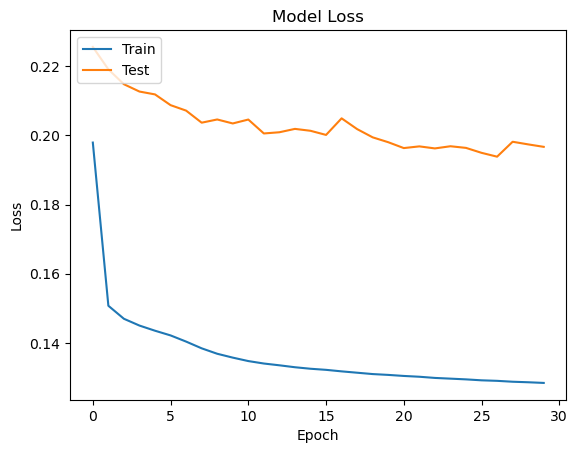

In [ ]:
#plot the loss
plt.plot(general_classifier.history.history['loss'])
plt.plot(general_classifier.history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()


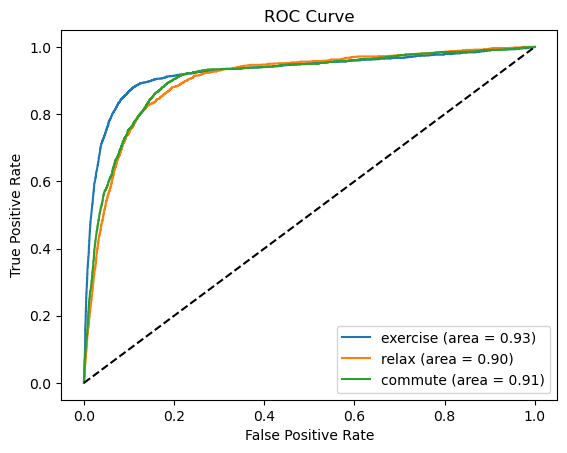

In [ ]:
#plot the auc roc curves for each activity
for i in range(3):
    y_pred = general_classifier.predict(gen_X_test, verbose=0)
    fpr, tpr, thresholds = roc_curve(gen_y_test.iloc[:, i], y_pred[:, i])
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, label='{} (area = {:.2f})'.format(gen_y_test.columns[i], auc_score))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
#print some random example predictions
for i in random.sample(range(len(gen_X_test)), 5):
    print('Predicted: ', general_classifier.predict(np.array([gen_X_test.iloc[i]]), verbose=0))
    print('Actual: ', np.array(gen_y_test.iloc[i]))
    print('')
        


Predicted:  [[0.01598609 0.00189763 0.05465012]]
Actual:  [0 0 0]

Predicted:  [[1.5403073e-02 3.2268558e-06 1.0231551e-02]]
Actual:  [0 0 0]

Predicted:  [[0.05778449 0.06820274 0.36041677]]
Actual:  [0 0 1]

Predicted:  [[1.7929977e-02 1.9764770e-05 6.0041705e-03]]
Actual:  [0 0 0]

Predicted:  [[0.68885994 0.08063491 0.22243145]]
Actual:  [1 0 1]



look at softmaxing the outputs

## Building a Multi Task Model

In [ ]:
#initializing weights
w1 = general_classifier.get_layer('shared_input_layer').get_weights()
w2 = general_classifier.get_layer('mid_dense_9').get_weights()
w3 = general_classifier.get_layer('mid_dense_7').get_weights()
w_output = general_classifier.get_layer('output_layer').get_weights()

#setting inputs
inputs = layers.Input(shape=(latent_dim,))
shared_input_layer = layers.Dense(12, activation='relu', name='shared_input_layer')(inputs)
shared_input_layer.set_weights(w1)

#dictionary for moodels for each user
user_models = {}

#get the number of user
users = users_data['user'].unique()

for user in users:

    mid_dense_9 = layers.Dense(9, activation='relu', name='mid_dense_9')(shared_input_layer)
    mid_dense_7 = layers.Dense(7, activation='relu', name='mid_dense_7')(mid_dense_9)
    output_layer = layers.Dense(3, activation='sigmoid', name='output_layer')(mid_dense_7)
    model = Model(inputs=inputs, outputs=output_layer)

    user_models[user] = model

    personal1 = user_models[user].get_layer('mid_dense_9')
    personal2 = user_models[user].get_layer('mid_dense_7')
    output = user_models[user].get_layer('output_layer')

    personal1.set_weights(w2)
    personal2.set_weights(w3)
    output.set_weights(w_output)
    
    personal1.trainable = True
    personal2.trainable = True
    output.trainable = True

In [ ]:
#creating dictionaries for my train and test sets whose keys are the user and values are the data
X_train_dict = dict()
y_train_dict = dict()
X_test_dict = dict()
y_test_dict = dict()

X_train_dict_df = dict()
y_train_dict_df = dict()
X_test_dict_df = dict()
y_test_dict_df = dict()

for user in y_train['user'].unique():
    X_train_dict_df[user] = X_train[y_train['user'] == user].drop(columns=['user'])
    y_train_dict_df[user] = y_train[y_train['user'] == user].drop(columns=['user'])
    X_test_dict_df[user] = X_test[y_test['user'] == user].drop(columns=['user'])
    y_test_dict_df[user] = y_test[y_test['user'] == user].drop(columns=['user'])


for user in y_train['user'].unique():
    X_train_dict[user] = X_train[y_train['user'] == user].drop(columns=['user']).values
    y_train_dict[user] = y_train[y_train['user'] == user].drop(columns=['user']).values
    X_test_dict[user] = X_test[y_test['user'] == user].drop(columns=['user']).values
    y_test_dict[user] = y_test[y_test['user'] == user].drop(columns=['user']).values

#print the shape of the train and test sets
for user in users:
    print('User: ', user)
    print('X_train shape: ', X_train_dict[user].shape)
    print('y_train shape: ', y_train_dict[user].shape)
    print('X_test shape: ', X_test_dict[user].shape)
    print('y_test shape: ', y_test_dict[user].shape)
    print('')

User:  2
X_train shape:  (20607, 12)
y_train shape:  (20607, 3)
X_test shape:  (5153, 12)
y_test shape:  (5153, 3)

User:  0
X_train shape:  (20608, 12)
y_train shape:  (20608, 3)
X_test shape:  (5152, 12)
y_test shape:  (5152, 3)

User:  1
X_train shape:  (20609, 12)
y_train shape:  (20609, 3)
X_test shape:  (5151, 12)
y_test shape:  (5151, 3)



In [ ]:
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.optimizers import Adam
from random import shuffle


def step(key_order, opt):
    # accumulate all the operations for the dataset
    preds = {} # each key will be a separate user
    loss = {}  # each key will be a separate user
    tapes = {} # each key will be a separate user
    single_loss = {}

    for x in key_order:
        with tf.GradientTape() as tape:
            tapes[x] = tape
            # make a prediction and calculate loss for each task
            preds[x] = user_models[x](X_train_dict[x])
            loss[x] = binary_crossentropy(y_train_dict[x], preds[x])
            single_loss[x] = binary_crossentropy(y_train_dict[x].ravel(), preds[x].numpy().ravel())
            
    # now batch update all the models with the gradients
    for x in key_order:
        grads = tapes[x].gradient(loss[x], user_models[x].trainable_variables)
        opt[x].apply_gradients(zip(grads, user_models[x].trainable_variables))

    y_all = np.concatenate([y_train_dict[x] for x in users]).ravel()
    yhat_all = np.concatenate([preds[x] for x in users]).ravel()

    single_loss['overall'] = binary_crossentropy(y_all, yhat_all)

    return single_loss


EPOCHS = 750

opt = {} # need separate optimizers for each output task
for x in users:
    opt[x] = Adam() # track 

train_losses = []
test_losses = []

for i in range(EPOCHS):
    print('Epoch',i,end=', ')
    shuffle(users) # shuffle in place operation, maybe not needed
    
    train_losses.append(step(users,opt)) # batched gradient updates

    y_mtl=[]
    yhat_mtl=[]

    valid_losses = {}
    for x in users:
        # test on data, for tracking
        yhat_mlp = user_models[x].predict(X_test_dict[x],verbose=0)
        y_mtl.append(y_test_dict[x].ravel())
        yhat_mtl.append(yhat_mlp.ravel())

        # calculate loss
        valid_losses[x] = binary_crossentropy(y_test_dict[x].ravel(), yhat_mlp.ravel())

    
    valid_losses['overall'] = binary_crossentropy(np.concatenate(y_mtl), np.concatenate(yhat_mtl))
    test_losses.append(valid_losses)

    print('Train loss:',np.array(train_losses[-1]['overall']),'Valid loss:',np.array(test_losses[-1]['overall']))

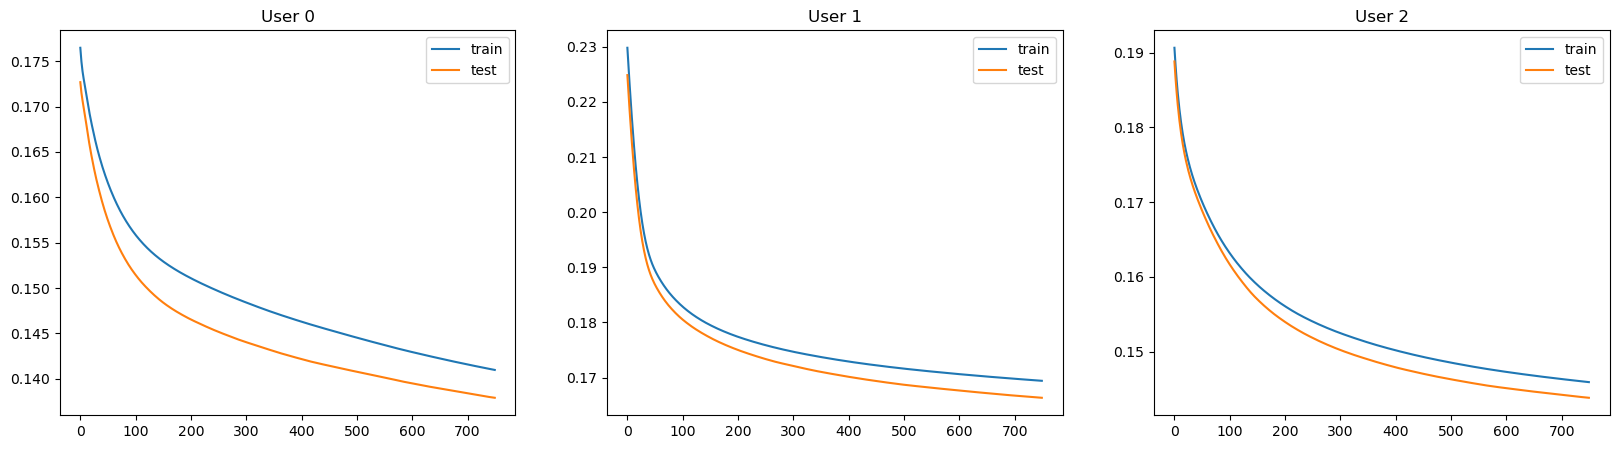

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

for user in users:
    train_loss = [train_losses[j][user] for j in range(len(train_losses))]
    test_loss = [test_losses[j][user] for j in range(len(test_losses))]
    axs[user].plot(train_loss, label='train')
    axs[user].plot(test_loss, label='test')
    axs[user].set_title('User ' + str(user))
    axs[user].legend()

plt.show()


Both User 1 and User 2 seem to have trained to convergence while User 0 has not quite converged. This may be due to more difficult user preferences. My testing loss is also interestingly lower than my training loss.

## Model Fine-Tuning

Further training while freezing the shared layer to allow each individual model to further spcify into their own tasks without influencing the other tasks. Also initializing the learning rate lower to account for previous training and for further specificity.

In [ ]:
EPOCHS = 250

shared_input_layer.trainable = False

opt = {} # need separate optimizers for each output task
for x in users:
    opt[x] = Adam(learning_rate=1e-4) # track 

train_losses = []
test_losses = []

for i in range(EPOCHS):
    print('Epoch',i,end=', ')
    shuffle(users) # shuffle in place operation, maybe not needed
    
    train_losses.append(step(users,opt)) # batched gradient updates

    y_mtl=[]
    yhat_mtl=[]

    valid_losses = {}
    for x in users:
        # test on data, for tracking
        yhat_mlp = user_models[x].predict(X_test_dict[x],verbose=0)
        y_mtl.append(y_test_dict[x].ravel())
        yhat_mtl.append(yhat_mlp.ravel())

        # calculate loss
        valid_losses[x] = binary_crossentropy(y_test_dict[x].ravel(), yhat_mlp.ravel())

    
    valid_losses['overall'] = binary_crossentropy(np.concatenate(y_mtl), np.concatenate(yhat_mtl))
    test_losses.append(valid_losses)

    print('Train loss:',np.array(train_losses[-1]['overall']),'Valid loss:',np.array(test_losses[-1]['overall']))

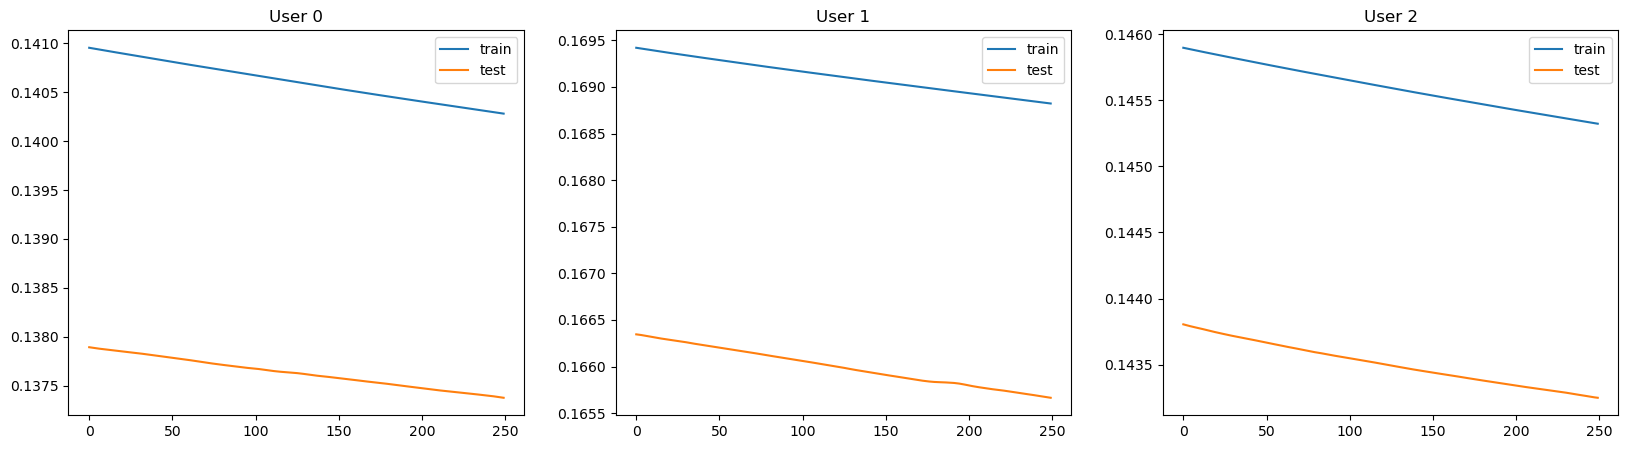

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

for user in users:
    train_loss = [train_losses[j][user] for j in range(len(train_losses))]
    test_loss = [test_losses[j][user] for j in range(len(test_losses))]
    axs[user].plot(train_loss, label='train')
    axs[user].plot(test_loss, label='test')
    axs[user].set_title('User ' + str(user))
    axs[user].legend()

plt.show()


After fine tuning and training for 250 more epochs, the losses are steaily decreading but the differences are so small so I dont think that further training will lead to significant model improvement. This may be becuase I initialized the learning rate very low, if the learning rate was greater, the model loss may have decreased more.